In [32]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
import warnings 
from pytz import timezone
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/Users/adrianaquinones/Downloads/delivery_data.csv")
print(f"Shape {df.shape}")
df = df.dropna()
df.head()

Shape (1000, 13)


,Customer placed order datetime,Placed order with restaurant datetime,Driver at restaurant datetime,Delivered to consumer datetime,Driver ID,Restaurant ID,Consumer ID,Delivery Region,Is ASAP,Order total,Amount of discount,Amount of tip,Refunded amount
0,26 11:21:31,26 11:25:31,26 11:33:31,26 11:44:31,413,117,92880,Santa Clara,False,15.87,0,9.19,0
1,27 10:39:35,27 10:45:35,27 10:59:35,27 11:12:35,131,96,48222,San Jose,False,31.47,10,7.71,5
2,05 14:17:19,05 14:24:19,05 14:35:19,05 14:40:19,485,136,12440,Santa Clara,False,66.87,0,8.93,5
3,16 10:00:03,16 10:10:03,16 10:21:03,16 10:29:03,330,31,91081,Santa Clara,True,42.52,0,5.96,5
4,07 03:52:10,07 04:01:10,07 04:14:10,07 04:22:10,230,199,48601,Santa Clara,False,28.69,0,0.58,0


In [6]:
time_cols = {
    'Customer placed order datetime': 'Customer',
    'Placed order with restaurant datetime': 'RestaurantOrder',
    'Driver at restaurant datetime': 'DriverArrive',
    'Delivered to consumer datetime': 'Delivered'
}
for col, prefix in time_cols.items():
    split_df = df[col].str.split(" ", n=1, expand=True)
    df[f"{prefix}_day"] = split_df[0]
    dt_utc = pd.to_datetime(split_df[1], format='%H:%M:%S')
    dt_pacific = dt_utc.dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

    df[f"{prefix}_Timestamp"] = dt_pacific

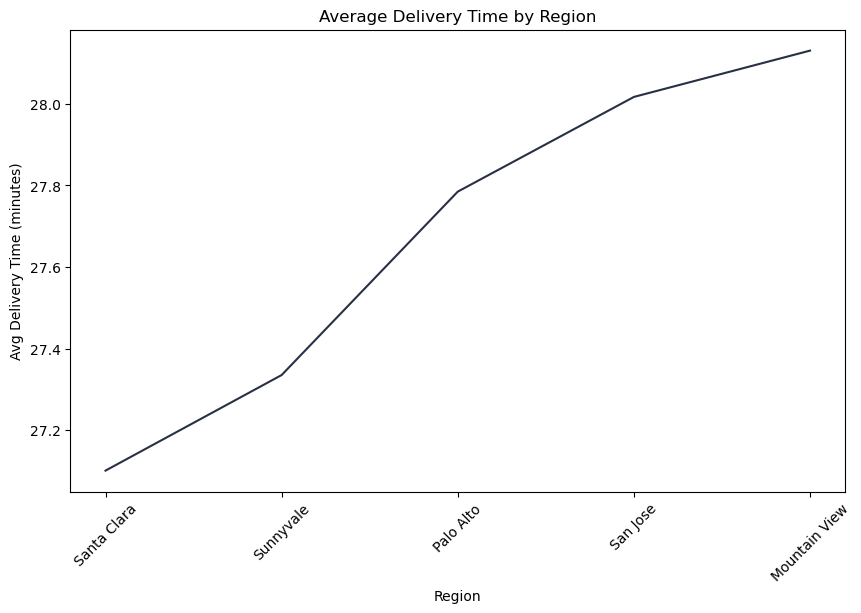

In [7]:

df['Delivery_duration_min'] = (df['Delivered_Timestamp'] - df['Customer_Timestamp']).dt.total_seconds() / 60

df.loc[df['Delivery_duration_min'] < 0, 'Delivery_duration_min'] += 24 * 60

avg_delivery_by_region = df.groupby('Delivery Region')['Delivery_duration_min'].mean().reset_index().sort_values('Delivery_duration_min')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(avg_delivery_by_region['Delivery Region'], avg_delivery_by_region['Delivery_duration_min'], color = '#283044')
ax.set_title('Average Delivery Time by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Avg Delivery Time (minutes)')
ax.set_xticklabels(avg_delivery_by_region['Delivery Region'], rotation=45)
plt.show()



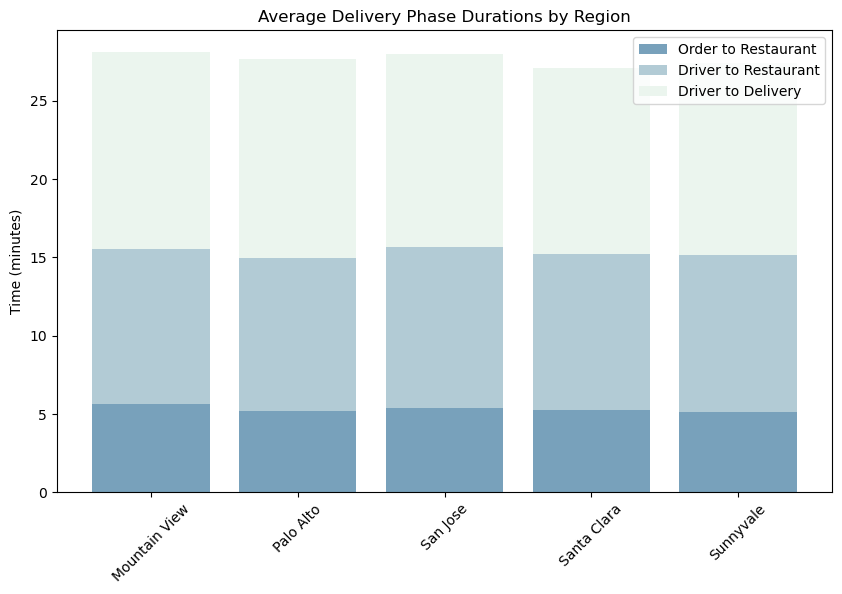

In [8]:
df['Order_to_Restaurant'] = (df['RestaurantOrder_Timestamp'] - df['Customer_Timestamp']).dt.total_seconds() / 60
df['Driver_to_Restaurant'] = (df['DriverArrive_Timestamp'] - df['RestaurantOrder_Timestamp']).dt.total_seconds() / 60
df['Driver_to_Delivery'] = (df['Delivered_Timestamp'] - df['DriverArrive_Timestamp']).dt.total_seconds() / 60

df = df[
    (df['Order_to_Restaurant'] >= 0) &
    (df['Driver_to_Restaurant'] >= 0) &
    (df['Driver_to_Delivery'] >= 0)
]

avg_times = df.groupby('Delivery Region')[[
    'Order_to_Restaurant',
    'Driver_to_Restaurant',
    'Driver_to_Delivery'
]].mean().reset_index()

regions = avg_times['Delivery Region']
x = np.arange(len(regions))

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x, avg_times['Order_to_Restaurant'], label='Order to Restaurant', color = '#78A1BB')
ax.bar(x, avg_times['Driver_to_Restaurant'], bottom=avg_times['Order_to_Restaurant'], label='Driver to Restaurant', color = '#B2CBD5')
ax.bar(
    x,
    avg_times['Driver_to_Delivery'],
    bottom=avg_times['Order_to_Restaurant'] + avg_times['Driver_to_Restaurant'],
    label='Driver to Delivery', color = '#EBF5EE'
)

ax.set_xticks(x)
ax.set_xticklabels(regions, rotation=45)
ax.set_ylabel('Time (minutes)')
ax.set_title('Average Delivery Phase Durations by Region')
ax.legend()
plt.show()


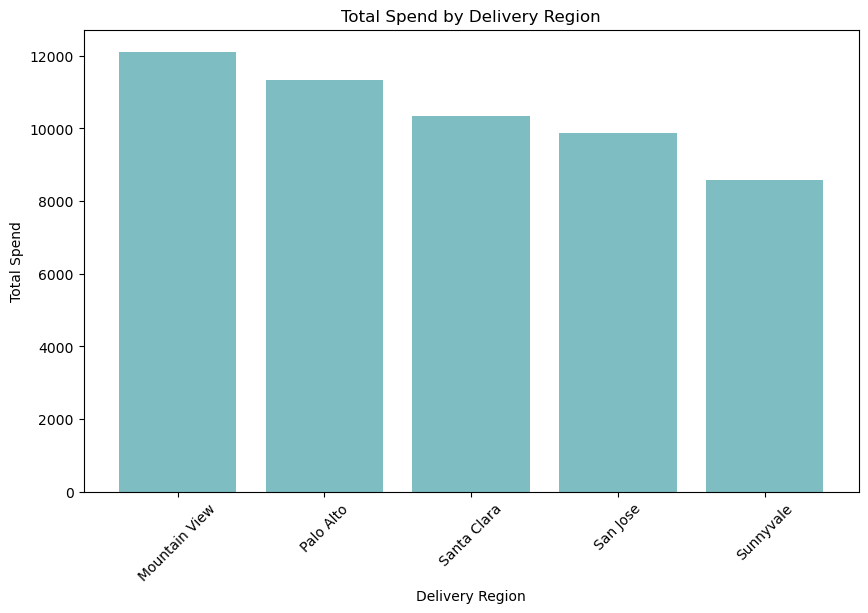

In [9]:
total_by_region = df.groupby('Delivery Region')['Order total'].sum().reset_index().sort_values('Order total', ascending= False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(total_by_region['Delivery Region'], total_by_region['Order total'], color = '#7EBDC2')  # Use the correct column name

ax.set_xlabel('Delivery Region')
ax.set_ylabel('Total Spend')
ax.set_title('Total Spend by Delivery Region')

plt.xticks(rotation=45) 
plt.show()


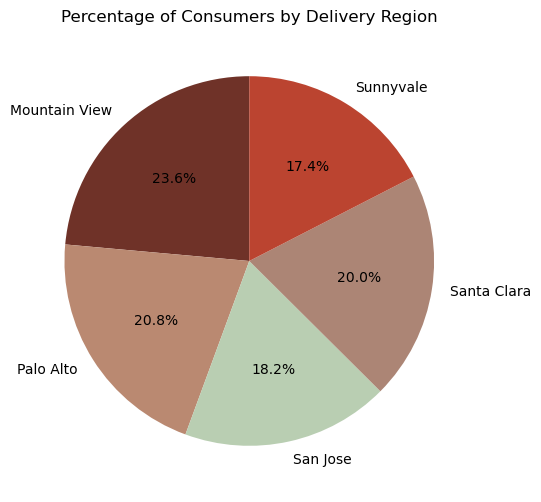

In [10]:
color_map ={
    'Mountain View' :'#6F3228',
    'Sunnyvale' : '#BB4430',
    'Palo Alto' : '#BA8971',
    'Santa Clara' : '#AC8575',
    'San Jose' : '#B9CEB2',
}
total_consumers = df['Consumer ID'].nunique()
consumers_by_region = df.groupby('Delivery Region')['Consumer ID'].nunique().reset_index()
consumers_by_region['percentage'] = (consumers_by_region['Consumer ID'] / total_consumers) * 100

colors = [color_map.get(region, '#D3D3D3') for region in consumers_by_region['Delivery Region']]

# Create the pie chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(consumers_by_region['percentage'], labels=consumers_by_region['Delivery Region'], autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title('Percentage of Consumers by Delivery Region')
plt.show()

<Axes: xlabel='Is ASAP', ylabel='Delivery_duration_min'>

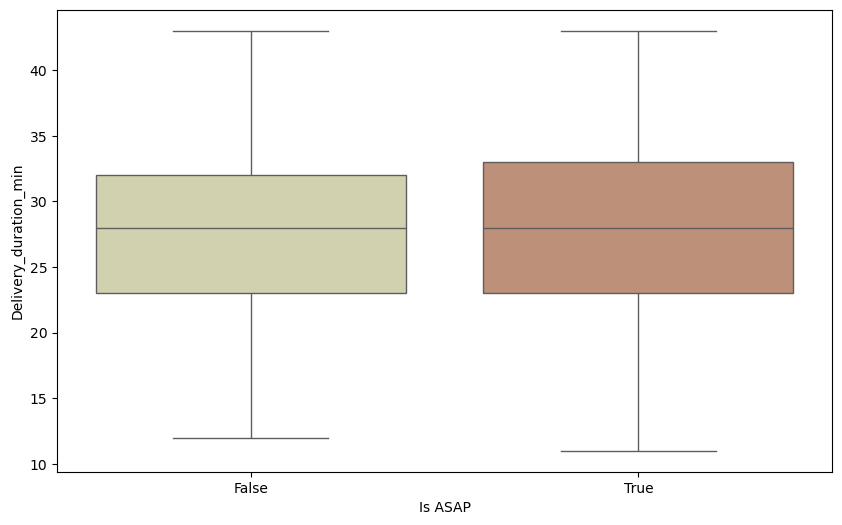

In [29]:
df['Delivery_duration_min'] = (df['Delivered_Timestamp'] - df['Customer_Timestamp']).dt.total_seconds() / 60
delivery_durations = df.groupby('Is ASAP')['Delivery_duration_min'].mean().reset_index()
hue_colors = {
    "True":"#C98E6D",
    "False":"#D6D7AA"
}
plt.figure(figsize=(10, 6))
sns.boxplot(data = df, x = 'Is ASAP', y = 'Delivery_duration_min', palette= hue_colors)


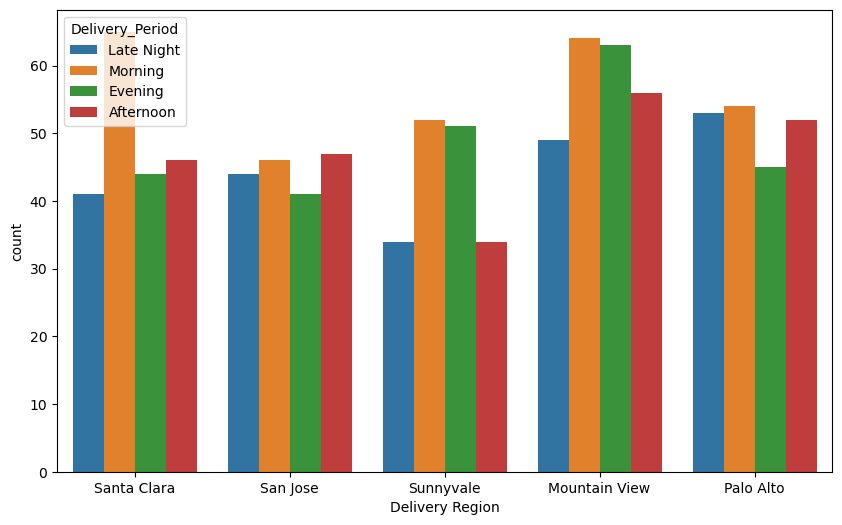

In [ ]:
df['Customer_hour'] = df['Customer_Timestamp'].dt.hour

conditions = [
    (df['Customer_hour'] >= 5) & (df['Customer_hour'] < 12),
    (df['Customer_hour'] >= 12) & (df['Customer_hour'] < 18),
    (df['Customer_hour'] >= 18) & (df['Customer_hour'] <= 23),
    (df['Customer_hour'] >= 0) & (df['Customer_hour'] < 5)
]
choices = ['Morning', 'Afternoon', 'Evening', 'Late Night']

df['Delivery_Period'] = np.select(conditions, choices, default='Unknown')

plt.figure(figsize=(10, 6))
sns.countplot(data = df, x = 'Delivery Region', hue = 'Delivery_Period')
plt.show()